### 文本測試

- 斷詞方法 (tokenizer) -> 2
    - jieba
    - CKIP
- 表示法（Representation） -> 3
    - R1：TF-IDF
    - R2：Word2Vec(mean)
    - R3：fastText(mean)
- 模型（Model） -> 6
    - M1：Logistic Regression
    - M2：SVM（RBF kernel；不要 linear）
    - M3：SVM（Polynomial kernel；補充用）
    - M4：Random Forest
    - M5：XGBoost
    - M6：Neural Network（MLP）

In [1]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties  
winfont01 = FontProperties(fname=r"c:\windows\fonts\simsun.ttc", size=12) 
winfont02 = FontProperties(fname=r"c:\windows\fonts\kaiu.ttf", size=12) 

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 設定字型為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                # 解決負號顯示問題

macfont = FontProperties(fname="/Library/Fonts/Arial Unicode.ttf", size=10) 

In [2]:
import sqlite3
import pandas as pd

DB_FILE = r"D:/NTPU_class/paper/code/mobile01_clawler/ntpu_paper.sqlite"

sql = """
WITH latest AS (
  SELECT
    article_id,
    MAX(created_at) AS max_created_at
  FROM eb_annotations
  WHERE level = 1
    AND article_id IS NOT NULL
  GROUP BY article_id
)
SELECT
  a.id          AS article_id,
  a.link_id     AS link_id,
  a.url         AS url,
  a.title       AS title,
  a.post_time   AS post_time,
  a.content     AS content,
  a.word_count  AS word_count,
  a.reply_count AS reply_count,

  l.keyword     AS keyword,
  l.has_emotional_abuse AS y_rule,  -- 你原本 links 裡的規則標註（如果還在用）

  -- ✅ 來自 eb_annotations（LLM/規則/分數）
  e.score_overall         AS y_llm_score,         -- 0~5
  e.confidence            AS llm_confidence,      -- 0~1（整體分析信心）
  e.is_eb_rule            AS y_rule_calc,         -- 0/1（你 calc_is_eb 的規則式判定）
  e.is_eb_llm             AS y_llm,               -- 0/1（LLM 二元判定）
  e.is_eb_llm_confidence  AS y_llm_confidence,    -- 0~1（LLM 二元信心）

  e.main_strategy,
  e.main_strategy_detail,
  e.pua_source,

  e.model_name,
  e.model_version,
  e.knowledge_base,
  e.created_at            AS anno_created_at
FROM articles a
JOIN links l
  ON a.link_id = l.id
LEFT JOIN latest t
  ON a.id = t.article_id
LEFT JOIN eb_annotations e
  ON e.article_id = t.article_id
 AND e.created_at = t.max_created_at
 AND e.level = 1
WHERE a.content IS NOT NULL
  AND TRIM(a.content) <> '';
"""

with sqlite3.connect(DB_FILE) as conn:
    df = pd.read_sql_query(sql, conn)

df.head()

,article_id,link_id,url,title,post_time,content,word_count,reply_count,keyword,y_rule,...,y_rule_calc,y_llm,y_llm_confidence,main_strategy,main_strategy_detail,pua_source,model_name,model_version,knowledge_base,anno_created_at
0,68fce9b6af1137205015fd06,68f87edcaf1137700cb26e94,https://www.mobile01.com/topicdetail.php?f=330...,被爸媽情緒勒索很痛苦 心理諮商有效嗎?,2024-12-10 9:53,大家都遇過父母情緒勒索嗎？從小我就是一個很聽話的小孩，因為我爸媽控制慾很重，如果不聽他們的話...,397,8,情緒勒索,1,...,1.0,1.0,0.9,power/emotion/blame,利用情感、控制慾和責任感來勒索子女,family,mistral,latest,pua_db,2026-02-10 09:38:45
1,68fce9f3af11377624f11eda,68f87edcaf1137700cb26e95,https://www.mobile01.com/topicdetail.php?f=292...,看完這篇其實 情緒勒索是不是也等於控制慾強?,2021-06-28 8:25,看完這篇其實 情緒勒索是不是也等於控制慾強?\n\n剛好在兩性版看到一段話 突然對控制慾強這...,2106,7,情緒勒索,1,...,1.0,1.0,1.0,power,使用憤怒和控制以獲得屌服的對象，並利用文字紀錄來強調自己的正確性,partner,mistral,latest,pua_db,2026-02-10 09:38:49
2,68fcea01af11377624f11edb,68f87edcaf1137700cb26e96,https://www.mobile01.com/topicdetail.php?f=37&...,沒有情緒勒索，只有忠言逆耳,2023-03-08 12:09,現在人(尤其是年輕人)遇到不好聽的話，就會說在情緒勒索他們\n實際上並不存在情緒勒索這種東西...,143,8,情緒勒索,1,...,1.0,0.0,1.0,emotion,利用反舉與責罪的方式，挑戰受眾的情感層面,online,mistral,latest,pua_db,2026-02-10 09:38:51
3,68fcea15af11377624f11edc,68f87edcaf1137700cb26e98,https://www.mobile01.com/topicdetail.php?f=594...,#書籍推薦 #不被情緒勒索的51個方法,2022-11-15 10:31,"(時間會證明,當初自己是對的...也會證明當初自己是錯的 ...?)\n(所以才需要每天寫日...",1248,0,情緒勒索,1,...,1.0,1.0,0.9,emotion,Using self-reflection and self-improvement tec...,self,mistral,latest,pua_db,2026-02-10 09:38:55
4,68fcea6eaf11379f9c929394,68f87edcaf1137700cb26e9c,https://www.mobile01.com/topicdetail.php?f=292...,有關情緒勒索,2023-09-07 16:49,請問各位，我有個疑問\n如果只是問另一半要不要吃飯\n或著是問一起出去玩好不好，\n又或者問...,63,8,情緒勒索,1,...,0.0,0.0,1.0,none,無情緒勒索，而是正常的互動或問題提出,online,mistral,latest,pua_db,2026-02-10 09:38:57


### 排除none的部分

In [3]:
import pandas as pd
import numpy as np

# 先複製
dfm = df.copy()

# 基本清理
dfm["y_rule"] = dfm["y_rule"].astype(int)
dfm["y_llm"] = pd.to_numeric(dfm["y_llm"], errors="coerce")

# ✅ 刪除未評分（y_llm 為 NaN）
before = len(dfm)
dfm = dfm.dropna(subset=["y_llm"]).reset_index(drop=True)
after = len(dfm)

before, after

(1428, 1385)

#### y_rule × y_llm 交叉表

In [4]:
ct = pd.crosstab(dfm["y_rule"], dfm["y_llm"], rownames=["y_rule"], colnames=["y_llm"], margins=True)
ct

y_llm,0.0,1.0,All
y_rule,,,
0,253,450,703
1,27,655,682
All,280,1105,1385


## 模型開始!~

In [5]:
import os, re, io, time, contextlib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# ===== optional: xgboost =====
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ===== Parameters (you can tune) =====
RANDOM_SEED = 42
TEST_SIZE = 0.2

Y_RAW_COL = "y_llm"          # 原始評分欄位
TEXT_COL  = "content"        # 主文文字欄位（留言就改 comment_text）

THRESHOLD = 3                # y_llm_bin：>=3 -> 1
N_WORKERS = max(1, (os.cpu_count() or 4) - 1)

TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 5
TFIDF_NGRAM = (1, 2)

SVD_DIM = 300                # TF-IDF 給 SVM/RF/XGB 用
EMB_DIM = 200                # w2v / fastText mean 維度
W2V_EPOCHS = 10
FT_EPOCHS  = 10

In [6]:
#  STEP 1｜斷詞函式（jieba + CKIP）
import jieba

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def tokenize_jieba(text: str):
    text = normalize_text(text)
    if not text:
        return []
    return [t for t in jieba.cut(text, cut_all=False) if t.strip()]

_CKIP_WS = None
def get_ckip_ws():
    global _CKIP_WS
    if _CKIP_WS is None:
        from ckip_transformers.nlp import CkipWordSegmenter
        f_out, f_err = io.StringIO(), io.StringIO()
        with contextlib.redirect_stdout(f_out), contextlib.redirect_stderr(f_err):
            _CKIP_WS = CkipWordSegmenter(model="bert-base")
    return _CKIP_WS

def tokenize_ckip(text: str):
    text = normalize_text(text)
    if not text:
        return []
    ws = get_ckip_ws()
    f_out, f_err = io.StringIO(), io.StringIO()
    with contextlib.redirect_stdout(f_out), contextlib.redirect_stderr(f_err):
        tokens = ws([text])[0]
    return [t for t in tokens if t.strip()]

c:\Users\USER\miniconda3\envs\ckip310\lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
# STEP 2｜Utility: timing + metrics
def timed(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return out, (time.perf_counter() - t0)

def eval_binary(y_true, pred, score):
    return {
        "acc": accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, score) if score is not None else np.nan,
        "pr_auc": average_precision_score(y_true, score) if score is not None else np.nan,
    }

In [8]:
# STEP 3｜資料定版：刪未評分 + 建 y
def prepare_dfm(df: pd.DataFrame,
                text_col=TEXT_COL,
                y_col="y_llm") -> pd.DataFrame:
    dfm = df.copy()
    dfm = dfm.dropna(subset=[y_col])
    dfm[text_col] = dfm[text_col].astype(str)

    # 保證是 0/1 int
    dfm[y_col] = pd.to_numeric(dfm[y_col], errors="coerce")
    dfm = dfm.dropna(subset=[y_col])
    dfm[y_col] = dfm[y_col].astype(int)
    return dfm

In [9]:
# STEP 4｜固定切分（df_train/df_test）
def split_df(dfm: pd.DataFrame, test_size=TEST_SIZE, seed=RANDOM_SEED):
    df_train, df_test = train_test_split(
        dfm,
        test_size=test_size,
        random_state=seed,
        stratify=dfm["y_llm"]
    )
    y_train = df_train["y_llm"].values
    y_test  = df_test["y_llm"].values
    return df_train, df_test, y_train, y_test


In [10]:
# STEP 4｜特徵工程（TF-IDF / w2v(mean) / fastText(mean)）
def make_tokens(df, text_col, tokenizer):
    return [tokenizer(t) for t in df[text_col].astype(str).tolist()]

def tokens_to_corpus(tokens):
    return [" ".join(t) for t in tokens]

def tfidf_train_test_from_tokens(tokens_tr, tokens_te,
                                 max_features=TFIDF_MAX_FEATURES,
                                 min_df=TFIDF_MIN_DF,
                                 ngram_range=TFIDF_NGRAM):
    corpus_tr = tokens_to_corpus(tokens_tr)
    corpus_te = tokens_to_corpus(tokens_te)

    vec = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range,
        dtype=np.float32
    )
    Xtr = vec.fit_transform(corpus_tr)
    Xte = vec.transform(corpus_te)
    return Xtr, Xte, vec

def mean_pool(tokens_list, wv, vector_size):
    X = np.zeros((len(tokens_list), vector_size), dtype=np.float32)
    cov = []
    for i, toks in enumerate(tokens_list):
        vecs = [wv[w] for w in toks if w in wv]
        if vecs:
            X[i] = np.mean(vecs, axis=0)
            cov.append(len(vecs) / max(len(toks), 1))
        else:
            cov.append(0.0)
    return X, float(np.mean(cov))

def w2v_mean_train_test(tokens_tr, tokens_te,
                        vector_size=EMB_DIM, window=5, min_count=2,
                        workers=N_WORKERS, epochs=W2V_EPOCHS):
    from gensim.models import Word2Vec
    model = Word2Vec(
        sentences=tokens_tr,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers
    )
    model.train(tokens_tr, total_examples=len(tokens_tr), epochs=epochs)
    Xtr, cov_tr = mean_pool(tokens_tr, model.wv, vector_size)
    Xte, cov_te = mean_pool(tokens_te, model.wv, vector_size)
    return Xtr, Xte, cov_tr, cov_te

def ft_mean_train_test(tokens_tr, tokens_te,
                       vector_size=EMB_DIM, window=5, min_count=2,
                       workers=N_WORKERS, epochs=FT_EPOCHS):
    from gensim.models import FastText
    model = FastText(
        sentences=tokens_tr,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers
    )
    model.train(tokens_tr, total_examples=len(tokens_tr), epochs=epochs)
    Xtr, cov_tr = mean_pool(tokens_tr, model.wv, vector_size)
    Xte, cov_te = mean_pool(tokens_te, model.wv, vector_size)
    return Xtr, Xte, cov_tr, cov_te


In [11]:
# STEP 5｜模型清單（LR / SVM-RBF / SVM-Poly / RF / XGB / MLP）
def build_models(seed=RANDOM_SEED):
    models = {}

    models["lr"] = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")

    models["svm_rbf"] = SVC(kernel="rbf", probability=True, class_weight="balanced")
    models["svm_poly"] = SVC(kernel="poly", degree=3, probability=True, class_weight="balanced")

    models["rf"] = RandomForestClassifier(
        n_estimators=600, random_state=seed, n_jobs=-1,
        class_weight="balanced_subsample"
    )

    if HAS_XGB:
        models["xgb"] = XGBClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1
        )

    models["mlp"] = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=40,
        early_stopping=True,
        random_state=seed
    )

    return models

In [12]:
# STEP 6｜評估函式（acc/f1/ROC-AUC/PR-AUC + train/test time）
def fit_eval(model, Xtr, Xte, ytr, yte, need_scale=False):
    # ---- train ----
    t0 = time.perf_counter()

    if need_scale:
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
        pipe.fit(Xtr, ytr)
        train_sec = time.perf_counter() - t0

        # ---- test predict ----
        t1 = time.perf_counter()
        pred = pipe.predict(Xte)
        score = pipe.predict_proba(Xte)[:, 1] if hasattr(pipe, "predict_proba") else None
        test_pred_sec = time.perf_counter() - t1

    else:
        model.fit(Xtr, ytr)
        train_sec = time.perf_counter() - t0

        t1 = time.perf_counter()
        pred = model.predict(Xte)
        score = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None
        test_pred_sec = time.perf_counter() - t1

    met = eval_binary(yte, pred, score)
    met["train_sec"] = train_sec
    met["test_pred_sec"] = test_pred_sec
    return met

In [13]:
# STEP 7｜主控：跑「全部組合矩陣」
def run_full_matrix(df_train, df_test, y_train, y_test,
                    text_col=TEXT_COL,
                    tokenize_map=None,
                    svd_dim=SVD_DIM,
                    seed=RANDOM_SEED):

    if tokenize_map is None:
        tokenize_map = {
            "jieba": tokenize_jieba,
            "ckip": tokenize_ckip
        }

    models = build_models(seed=seed)
    rows = []

    all_model_names = ["lr", "svm_rbf", "svm_poly", "rf", "mlp"] + (["xgb"] if "xgb" in models else [])

    for tok_name, tok_fn in tokenize_map.items():

        # ---- A) tokenize cache ----
        (tok_tr, tok_te), prep_sec = timed(
            lambda: (make_tokens(df_train, text_col, tok_fn),
                     make_tokens(df_test,  text_col, tok_fn))
        )

        # ---- B) TF-IDF ----
        (Xtr_tfidf, Xte_tfidf, _), tfidf_sec = timed(tfidf_train_test_from_tokens, tok_tr, tok_te)

        # TF-IDF：LR 用 sparse
        met = fit_eval(models["lr"], Xtr_tfidf, Xte_tfidf, y_train, y_test, need_scale=False)
        rows.append({
            "tokenizer": tok_name, "repr": "tfidf", "model": "lr",
            "prep_sec": prep_sec, "feat_sec": tfidf_sec, **met
        })

        # TF-IDF：其他模型走 SVD dense
        svd = TruncatedSVD(n_components=svd_dim, random_state=seed)
        t0 = time.perf_counter()
        Xtr_svd = svd.fit_transform(Xtr_tfidf)
        Xte_svd = svd.transform(Xte_tfidf)
        svd_sec = time.perf_counter() - t0

        for mname in [m for m in all_model_names if m != "lr"]:
            need_scale = (mname.startswith("svm") or mname in ["mlp"])
            met = fit_eval(models[mname], Xtr_svd, Xte_svd, y_train, y_test, need_scale=need_scale)
            rows.append({
                "tokenizer": tok_name,
                "repr": f"tfidf_svd{svd_dim}",
                "model": mname,
                "prep_sec": prep_sec,
                "feat_sec": (tfidf_sec + svd_sec),
                **met
            })

        # ---- C) Word2Vec(mean) ----
        (Xtr_w2v, Xte_w2v, cov_tr, cov_te), w2v_sec = timed(w2v_mean_train_test, tok_tr, tok_te)

        for mname in all_model_names:
            need_scale = (mname.startswith("svm") or mname in ["lr", "mlp"])
            met = fit_eval(models[mname], Xtr_w2v, Xte_w2v, y_train, y_test, need_scale=need_scale)
            rows.append({
                "tokenizer": tok_name, "repr": "w2v_mean", "model": mname,
                "cov_train": cov_tr, "cov_test": cov_te,
                "prep_sec": prep_sec, "feat_sec": w2v_sec, **met
            })

        # ---- D) fastText(mean) ----
        (Xtr_ft, Xte_ft, cov_tr, cov_te), ft_sec = timed(ft_mean_train_test, tok_tr, tok_te)

        for mname in all_model_names:
            need_scale = (mname.startswith("svm") or mname in ["lr", "mlp"])
            met = fit_eval(models[mname], Xtr_ft, Xte_ft, y_train, y_test, need_scale=need_scale)
            rows.append({
                "tokenizer": tok_name, "repr": "fasttext_mean", "model": mname,
                "cov_train": cov_tr, "cov_test": cov_te,
                "prep_sec": prep_sec, "feat_sec": ft_sec, **met
            })

    res = pd.DataFrame(rows)

    # total time = tokenize + feature + train + test_pred
    if "test_pred_sec" in res.columns:
        res["total_sec"] = (res["prep_sec"] + res["feat_sec"] + res["train_sec"] + res["test_pred_sec"]).astype(float)
    else:
        # fallback（如果你還沒升級 fit_eval）
        res["total_sec"] = (res["prep_sec"] + res["feat_sec"] + res["train_sec"]).astype(float)

    # round
    for c in ["acc","f1","roc_auc","pr_auc","prep_sec","feat_sec","train_sec","test_pred_sec","total_sec","cov_train","cov_test"]:
        if c in res.columns:
            res[c] = res[c].astype(float).round(3)

    # sort
    sort_cols = [c for c in ["roc_auc","pr_auc","f1"] if c in res.columns]
    res = res.sort_values(sort_cols, ascending=False).reset_index(drop=True)
    return res


In [14]:
# main
# STEP A：準備 dfm
dfm = prepare_dfm(df, text_col=TEXT_COL, y_col="y_llm")
dfm["y_llm"].value_counts()

# STEP B：切分
df_train, df_test, y_train, y_test = split_df(dfm, test_size=TEST_SIZE, seed=RANDOM_SEED)

# STEP C：先只跑 jieba（快確認流程）
tokenize_map = {"jieba": tokenize_jieba}
df_res_jieba = run_full_matrix(df_train, df_test, y_train, y_test, text_col=TEXT_COL, tokenize_map=tokenize_map)
df_res_jieba.head(20)

# STEP D：再加 CKIP（完整跑）
tokenize_map = {
    "jieba": tokenize_jieba, 
    "ckip": tokenize_ckip
    }
# tokenizer × repr × model
df_res = run_full_matrix(df_train, df_test, y_train, y_test, text_col=TEXT_COL, tokenize_map=tokenize_map)
df_res.head(30)

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\USER\AppData\Local\Temp\jieba.cache
Loading model cost 0.552 seconds.
Prefix dict has been built successfully.


KeyboardInterrupt: 

### 整理輸出的部分

PR-AUC：模型是否能穩定地抓到情緒勒索 <br>
ROC-AUC：即使模型亂預測，也可能看起來很高

In [ ]:
def output_final_table(df_res, top_n=30, n_train=None, n_test=None):
    out = df_res.copy()

    # === 定義你這次報告用的時間 ===
    # 只看模型訓練時間（不含斷詞/特徵）
    out["train_time"] = out["train_sec"]
    # 只看模型推論時間（不含斷詞/特徵）
    out["test_time"]  = out["test_pred_sec"]

    # 每篇平均（只用模型時間）
    if n_train is not None:
        out["train_sec_per_doc"] = out["train_time"] / max(int(n_train), 1)
    if n_test is not None:
        out["test_sec_per_doc"] = out["test_time"] / max(int(n_test), 1)

    cols = [
        "tokenizer", "repr", "model",
        "pr_auc", "roc_auc",
        "train_time", "test_time",
        "train_sec_per_doc", "test_sec_per_doc"
    ]
    cols = [c for c in cols if c in out.columns]
    out = out[cols]

    if "pr_auc" in out.columns:
        out = out.sort_values("pr_auc", ascending=False)
    out = out.head(top_n).reset_index(drop=True)

    # 四捨五入，好看
    for c in ["pr_auc", "roc_auc", "train_time", "test_time"]:
        if c in out.columns:
            out[c] = out[c].astype(float).round(3)
    for c in ["train_sec_per_doc", "test_sec_per_doc"]:
        if c in out.columns:
            out[c] = out[c].astype(float).round(6)

    return out

df_report = output_final_table(df_res, top_n=20, n_train=len(df_train), n_test=len(df_test))
df_report

,tokenizer,repr,model,pr_auc,roc_auc,train_time,test_time,train_sec_per_doc,test_sec_per_doc
0,ckip,w2v_mean,svm_rbf,0.976,0.908,0.169,0.027,0.000153,0.000097
1,ckip,w2v_mean,svm_poly,0.976,0.907,0.117,0.009,0.000106,0.000032
2,jieba,tfidf,lr,0.975,0.902,0.002,0.000,0.000002,0.000000
3,ckip,fasttext_mean,mlp,0.975,0.901,0.371,0.003,0.000335,0.000011
4,jieba,w2v_mean,svm_rbf,0.975,0.896,0.151,0.025,0.000136,0.000090
5,ckip,tfidf_svd300,xgb,0.975,0.898,1.952,0.004,0.001762,0.000014
6,ckip,w2v_mean,lr,0.974,0.902,0.052,0.001,0.000047,0.000004
7,ckip,fasttext_mean,svm_rbf,0.974,0.900,0.185,0.027,0.000167,0.000097
8,ckip,w2v_mean,mlp,0.974,0.899,0.206,0.003,0.000186,0.000011
9,ckip,tfidf,lr,0.974,0.898,0.003,0.000,0.000003,0.000000


- train_time (= train_sec)：整批訓練一次模型所需時間（不是每篇文件各自訓練的時間）。
- test_time (= test_pred_sec)：整批測試資料推論一次所需時間（不是單篇推論時間）。
- train_sec_per_doc = train_sec / n_train
- test_sec_per_doc = test_pred_sec / n_test

由表可知，各模型組合在 PR-AUC 與 ROC-AUC 上表現差異不大，整體皆達到穩定水準。其中 SVM 搭配詞向量表示（如 w2v_mean）表現略為突出。從時間成本來看，模型間差異主要體現在訓練時間，推論時間普遍極低；傳統線性模型（如 LR）在維持良好效能的同時，具備較低訓練成本，顯示其在效率與效果間取得良好平衡。

離線分析：ckip + w2v_mean / fasttext_mean + svm <br>
即時應用：Jieba + TF-IDF + lr

### CKIP 壓力測試（字數 vs 速度）


In [ ]:
# 以資料庫內最長內容做基準，切不同字數測試
import numpy as np

# 取最長文章（若無 word_count 則用字元長度）
if 'word_count' in dfm.columns:
    long_text = dfm.sort_values('word_count', ascending=False)['content'].iloc[0]
else:
    long_text = dfm['content'].astype(str).map(len).sort_values(ascending=False).index
    long_text = dfm.loc[long_text[0], 'content']

long_text = normalize_text(long_text)

lengths = [200, 500, 1000, 2000, 4000, 8000, 12000, 16000, 20000]
repeats = 3

def bench_ckip(text, repeats=3):
    times = []
    tokens = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        toks = tokenize_ckip(text)
        dt = time.perf_counter() - t0
        times.append(dt)
        tokens = toks
    return float(np.mean(times)), len(tokens) if tokens is not None else 0

rows = []
for L in lengths:
    sample = long_text[:L]
    sec, n_tok = bench_ckip(sample, repeats=repeats)
    rows.append({
        'chars': L,
        'tokens': n_tok,
        'sec_avg': sec,
        'sec_per_1k_chars': sec / max(L, 1) * 1000,
    })

df_ckip_bench = pd.DataFrame(rows)
df_ckip_bench


,chars,tokens,sec_avg,sec_per_1k_chars
0,200,113,0.092986,0.464932
1,500,228,0.191669,0.383337
2,1000,469,0.363504,0.363504
3,2000,1032,0.700092,0.350046
4,4000,1201,0.950619,0.237655
5,8000,1201,0.903115,0.112889
6,12000,1201,0.896507,0.074709
7,16000,1201,0.918183,0.057386
8,20000,1201,0.942324,0.047116


文字經過 CKIP 斷詞後，被切分成多少個詞（token） <br>
觀察 token 數量可發現，約 4000 字後 token 數固定於 1201，推測 CKIP 存在最大輸入長度限制，因此超長文本僅部分參與模型運算。然而本研究資料為社群貼文，實際字數遠低於該上限，故不影響實驗結果。

In [ ]:
# 找出明顯變慢的轉折點（sec_per_1k_chars 明顯上升）
df_ckip_bench['ratio_vs_prev'] = df_ckip_bench['sec_per_1k_chars'] / df_ckip_bench['sec_per_1k_chars'].shift(1)
slow = df_ckip_bench[df_ckip_bench['ratio_vs_prev'] > 1.5].head(1)
slow


,chars,tokens,sec_avg,sec_per_1k_chars,ratio_vs_prev


找出第一個「比上一筆慢 50% 以上」的點
結果沒有

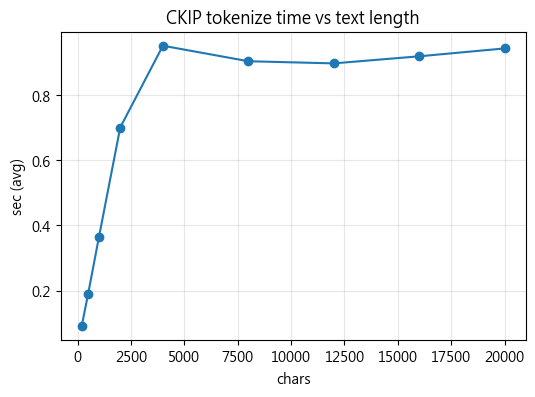

In [ ]:
# 簡單視覺化
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(df_ckip_bench['chars'], df_ckip_bench['sec_avg'], marker='o')
plt.xlabel('chars')
plt.ylabel('sec (avg)')
plt.title('CKIP tokenize time vs text length')
plt.grid(True, alpha=0.3)
plt.show()


CKIP 斷詞時間於 4000 字後趨於穩定，未觀察到隨字數持續爆增之現象。